In [60]:
import pandas as pd
from datetime import datetime
from pathlib import Path
import csv
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [61]:
clean_data = "data\\processed\\captures1_v2\\clean\\eth2dump-clean-1h_1.csv"
mitm_data = "data\\processed\\captures1_v2\\mitm\\eth2dump-mitm-change-5m-1h_1.csv"

absolute_clean_path = (Path("../..") / clean_data).resolve()
absolute_mitm_path = (Path("../..") / mitm_data).resolve()

# Print the absolute paths
print("Absolute path to clean data:", absolute_clean_path)
print("Absolute path to mitm data:", absolute_mitm_path)

Absolute path to clean data: C:\Users\jorel\OneDrive\Documents\CODE STUFF\DOE\BNL\foundational_model_for_energy_security\data\processed\captures1_v2\clean\eth2dump-clean-1h_1.csv
Absolute path to mitm data: C:\Users\jorel\OneDrive\Documents\CODE STUFF\DOE\BNL\foundational_model_for_energy_security\data\processed\captures1_v2\mitm\eth2dump-mitm-change-5m-1h_1.csv


In [62]:
clean_data = pd.read_csv(absolute_clean_path)
mitm_data = pd.read_csv(absolute_mitm_path)

print(clean_data.columns.tolist())
display(clean_data.head())

['packet_number', 'timestamp', 'datetime', 'protocols', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'tcp_len', 'transaction_id', 'protocol_id', 'modbus_length', 'unit_id', 'function_code', 'reference_num', 'word_count', 'bit_count', 'byte_count', 'exception_code', 'pkt_len', 'is_request', 'is_response', 'is_exception', 'function_name', 'inter_arrival_time', 'time_from_start', 'rolling_iat_mean', 'rolling_iat_std', 'requests_per_second', 'flow_id', 'flow_pkt_count', 'unique_func_codes', 'round_trip_time']


,packet_number,timestamp,datetime,protocols,src_ip,dst_ip,src_port,dst_port,tcp_len,transaction_id,...,function_name,inter_arrival_time,time_from_start,rolling_iat_mean,rolling_iat_std,requests_per_second,flow_id,flow_pkt_count,unique_func_codes,round_trip_time
0,3,1.536440e+09,2018-09-08T16:54:30.205937,Modbus/TCP,172.27.224.70,172.27.224.250,49205,502,12,0,...,Read Holding Registers,NaN,0.000000,NaN,NaN,1,172.27.224.250_172.27.224.70,1,1,0.003102
1,4,1.536440e+09,2018-09-08T16:54:30.209039,Modbus/TCP,172.27.224.250,172.27.224.70,502,49205,31,0,...,Read Holding Registers,0.003102,0.003102,0.003102,NaN,1,172.27.224.250_172.27.224.70,2,1,0.003102
2,6,1.536440e+09,2018-09-08T16:54:30.517529,Modbus/TCP,172.27.224.70,172.27.224.250,49205,502,12,0,...,Read Holding Registers,0.308490,0.311592,0.155796,0.215942,2,172.27.224.250_172.27.224.70,3,1,0.010858
3,7,1.536440e+09,2018-09-08T16:54:30.528387,Modbus/TCP,172.27.224.250,172.27.224.70,502,49205,31,0,...,Read Holding Registers,0.010858,0.322450,0.107483,0.174120,2,172.27.224.250_172.27.224.70,4,1,0.010858
4,10,1.536440e+09,2018-09-08T16:54:30.829737,Modbus/TCP,172.27.224.70,172.27.224.250,49205,502,12,0,...,Read Holding Registers,0.301350,0.623800,0.155950,0.172070,3,172.27.224.250_172.27.224.70,5,1,0.009315


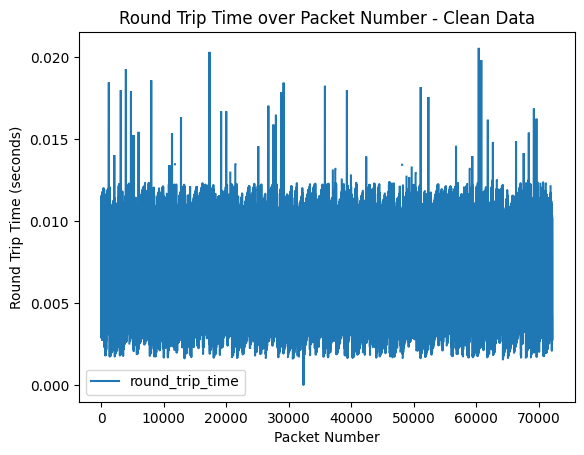

In [63]:
clean_data.plot(kind='line', x='packet_number', y='round_trip_time', title='Round Trip Time over Packet Number - Clean Data')
plt.xlabel('Packet Number')
plt.ylabel('Round Trip Time (seconds)')
plt.show()

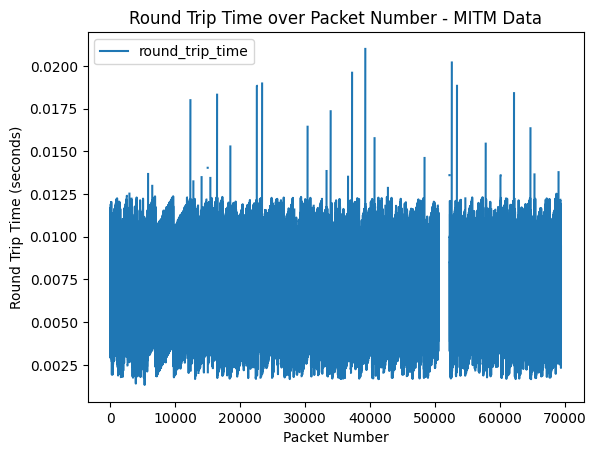

In [64]:
mitm_data.plot(kind='line', x='packet_number', y='round_trip_time', title='Round Trip Time over Packet Number - MITM Data')
plt.xlabel('Packet Number')
plt.ylabel('Round Trip Time (seconds)')
plt.show()